# Transfer Leanring Part 3: Scaling up Exercises

In [1]:
# Get helper functions file
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py

--2026-05-17 09:04:37--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-05-17 09:04:37 (121 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [2]:
from helper_functions import unzip_data, plot_loss_curves, compare_historys, walk_through_dir, make_confusion_matrix

## Get data

In [3]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip

unzip_data('101_food_classes_10_percent.zip')

--2026-05-17 09:04:44--  https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 172.217.218.207, 142.251.31.207, 142.250.153.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.217.218.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1625420029 (1.5G) [application/zip]
Saving to: ‘101_food_classes_10_percent.zip’

101_food_classes_10 100%[===================>]   1.51G  41.8MB/s    in 49s     

2026-05-17 09:05:34 (31.4 MB/s) - ‘101_food_classes_10_percent.zip’ saved [1625420029/1625420029]



In [4]:
# Walk through the directory

data_dir = '101_food_classes_10_percent'

walk_through_dir(data_dir)

There are 2 directories and 0 images in '101_food_classes_10_percent'.
There are 101 directories and 0 images in '101_food_classes_10_percent/train'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/oysters'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/ramen'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/pork_chop'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/nachos'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/escargots'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/strawberry_shortcake'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/fried_calamari'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/eggs_benedict'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/tacos'.
There are 0 directories and 75 images in '101_food_

In [5]:
import tensorflow as tf

train_dir = data_dir + '/' + 'train/'
test_dir = data_dir + '/' + 'test/'

In [6]:
BATCH_SIZE = 32
IMG_SIZE = (224,224)

train_data, val_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    shuffle=True,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset='both',
    seed=42
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

len(train_data), len(val_data), len(test_data)

Found 7575 files belonging to 101 classes.
Using 6060 files for training.
Using 1515 files for validation.
Found 25250 files belonging to 101 classes.


(190, 48, 790)

In [7]:
class_names = test_data.class_names

## Get the model ready

In [8]:
from tensorflow.keras import layers, Sequential, Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input

In [9]:
data_augmentation = Sequential([
    layers.RandomRotation(0.2),
    layers.RandomWidth(0.2),
    layers.RandomHeight(0.2),
    layers.RandomFlip('horizontal'),
    layers.RandomZoom(0.2)
])

base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE+(3,), name='input_layer')
x = data_augmentation(inputs)
x = base_model(x)
x = GlobalAveragePooling2D(name='GAP_layer')(x)
outputs = Dense(len(class_names), activation='softmax', name='output_layer')(x)

model = Model(inputs, outputs)

model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, None, None,     │     5,919,312 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP_layer                       │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 101)            │       129,381 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,048,693 (23.07 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [10]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [11]:
def create_checkpoint(filepath, monitor='val_accuracy',flag=True):
  checkpoint = ModelCheckpoint(filepath=filepath,
                               monitor=monitor,
                               save_best_only=flag)
  return checkpoint

In [12]:
# compile and fit hte model
model.compile(
    loss='categorical_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

history_feature_extractions = model.fit(
    train_data,
    steps_per_epoch=len(train_data),
    validation_data=val_data,
    validation_steps=len(val_data),
    epochs=5,
    callbacks=[create_checkpoint('feature_extraction.keras')]
)

Epoch 1/5
190/190 ━━━━━━━━━━━━━━━━━━━━ 87s 372ms/step - accuracy: 0.2046 - loss: 3.7194 - val_accuracy: 0.3683 - val_loss: 2.8145
Epoch 2/5
190/190 ━━━━━━━━━━━━━━━━━━━━ 63s 329ms/step - accuracy: 0.4053 - loss: 2.6556 - val_accuracy: 0.4469 - val_loss: 2.3058
Epoch 3/5
190/190 ━━━━━━━━━━━━━━━━━━━━ 54s 286ms/step - accuracy: 0.4787 - loss: 2.2607 - val_accuracy: 0.4865 - val_loss: 2.0752
Epoch 4/5
190/190 ━━━━━━━━━━━━━━━━━━━━ 52s 276ms/step - accuracy: 0.5223 - loss: 2.0104 - val_accuracy: 0.5069 - val_loss: 1.9524
Epoch 5/5
190/190 ━━━━━━━━━━━━━━━━━━━━ 49s 258ms/step - accuracy: 0.5460 - loss: 1.8666 - val_accuracy: 0.5300 - val_loss: 1.8715


In [14]:
# Evaluate model on test data
results_feature_extraction = model.evaluate(test_data)
results_feature_extraction

790/790 ━━━━━━━━━━━━━━━━━━━━ 57s 72ms/step - accuracy: 0.5497 - loss: 1.7440


[1.7439992427825928, 0.5497029423713684]

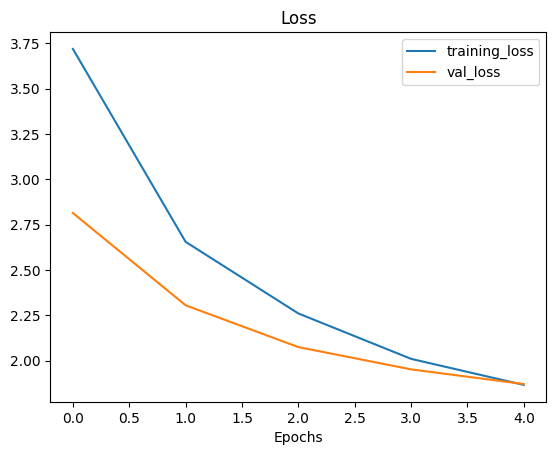

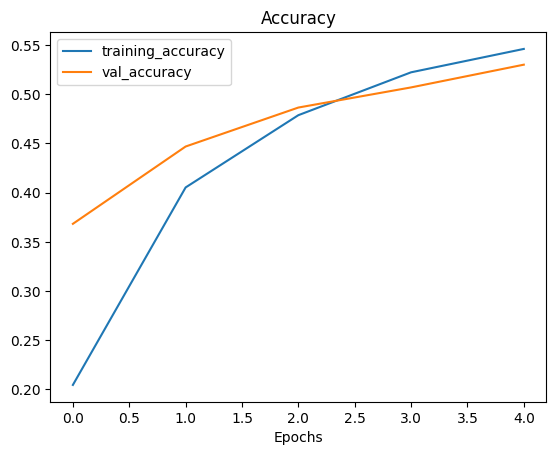

In [15]:
plot_loss_curves(history_feature_extractions)

In [17]:
# Use the same model and complete 10 epochs
history_feature_extraction_10_epochs = model.fit(
    train_data,
    steps_per_epoch=len(train_data),
    validation_data=val_data,
    validation_steps=len(val_data),
    initial_epoch=history_feature_extractions.epoch[-1],
    epochs=10
)

Epoch 5/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 44s 231ms/step - accuracy: 0.5710 - loss: 1.7477 - val_accuracy: 0.5320 - val_loss: 1.8214
Epoch 6/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 78s 211ms/step - accuracy: 0.5969 - loss: 1.6504 - val_accuracy: 0.5366 - val_loss: 1.8013
Epoch 7/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 39s 205ms/step - accuracy: 0.6155 - loss: 1.5646 - val_accuracy: 0.5485 - val_loss: 1.7679
Epoch 8/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 36s 190ms/step - accuracy: 0.6287 - loss: 1.4931 - val_accuracy: 0.5452 - val_loss: 1.7472
Epoch 9/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 36s 186ms/step - accuracy: 0.6531 - loss: 1.4090 - val_accuracy: 0.5512 - val_loss: 1.7308
Epoch 10/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 33s 172ms/step - accuracy: 0.6517 - loss: 1.3891 - val_accuracy: 0.5644 - val_loss: 1.7173


In [18]:
results_feature_extraction_10_epochs = model.evaluate(test_data)
results_feature_extraction_10_epochs

790/790 ━━━━━━━━━━━━━━━━━━━━ 53s 67ms/step - accuracy: 0.5831 - loss: 1.5638


[1.5638411045074463, 0.5831286907196045]

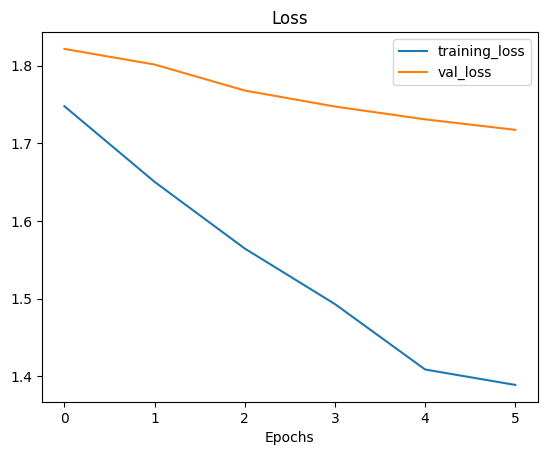

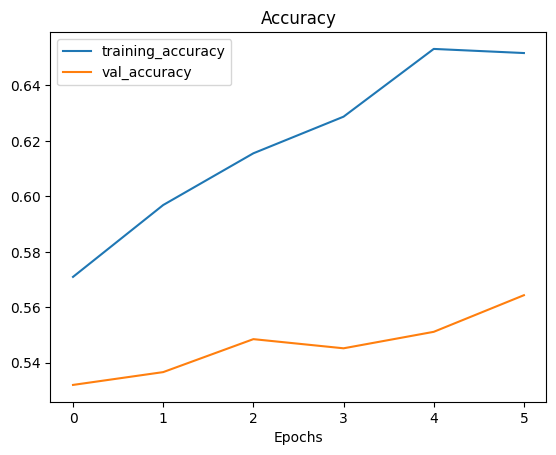

In [19]:
plot_loss_curves(history_feature_extraction_10_epochs)

In [21]:
# Now change the model up for fine tuning
model_1 = tf.keras.models.load_model('feature_extraction.keras')

In [22]:
# Reconfirm the evaluation scores
model_1.evaluate(test_data)

790/790 ━━━━━━━━━━━━━━━━━━━━ 59s 68ms/step - accuracy: 0.5497 - loss: 1.7440


[1.74399995803833, 0.5497029423713684]

In [23]:
# Unfreeze some layers
for layer in model_1.layers[2].layers[-10:]:
  layer.trainable=True

for layer_number, layer in enumerate(model_1.layers[2].layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer True
1 rescaling False
2 normalization False
3 stem_conv False
4 stem_bn False
5 stem_activation False
6 block1a_project_conv False
7 block1a_project_bn False
8 block1a_project_activation False
9 block2a_expand_conv False
10 block2a_expand_bn False
11 block2a_expand_activation False
12 block2a_project_conv False
13 block2a_project_bn False
14 block2b_expand_conv False
15 block2b_expand_bn False
16 block2b_expand_activation False
17 block2b_project_conv False
18 block2b_project_bn False
19 block2b_drop False
20 block2b_add False
21 block3a_expand_conv False
22 block3a_expand_bn False
23 block3a_expand_activation False
24 block3a_project_conv False
25 block3a_project_bn False
26 block3b_expand_conv False
27 block3b_expand_bn False
28 block3b_expand_activation False
29 block3b_project_conv False
30 block3b_project_bn False
31 block3b_drop False
32 block3b_add False
33 block4a_expand_conv False
34 block4a_expand_bn False
35 block4a_expand_activation False
36 block4a_dwconv2 F

In [24]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')

In [25]:
# Recompile the model
model_1.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

# Fit the model for fine tuning
history_fine_tuning = model_1.fit(
    train_data,
    validation_data=val_data,
    validation_steps=len(val_data),
    steps_per_epoch=len(train_data),
    initial_epoch=history_feature_extractions.epoch[-1],
    epochs=10
)

Epoch 5/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 53s 196ms/step - accuracy: 0.5627 - loss: 1.9339 - val_accuracy: 0.5175 - val_loss: 1.8809
Epoch 6/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 34s 181ms/step - accuracy: 0.6069 - loss: 1.7412 - val_accuracy: 0.5353 - val_loss: 1.8111
Epoch 7/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 34s 177ms/step - accuracy: 0.6137 - loss: 1.6724 - val_accuracy: 0.5373 - val_loss: 1.7582
Epoch 8/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 30s 156ms/step - accuracy: 0.6325 - loss: 1.5803 - val_accuracy: 0.5380 - val_loss: 1.7307
Epoch 9/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 33s 171ms/step - accuracy: 0.6439 - loss: 1.5191 - val_accuracy: 0.5518 - val_loss: 1.6992
Epoch 10/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 31s 162ms/step - accuracy: 0.6543 - loss: 1.4824 - val_accuracy: 0.5597 - val_loss: 1.6766


In [28]:
# Evaluate on test data
results_fine_tuning = model_1.evaluate(test_data)
results_fine_tuning

790/790 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.5956 - loss: 1.5133


[1.513292670249939, 0.5955643653869629]

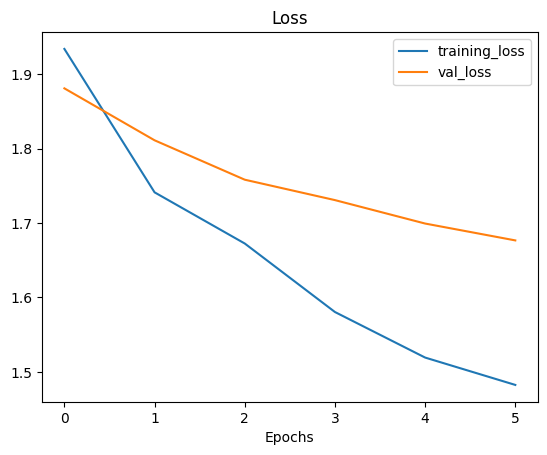

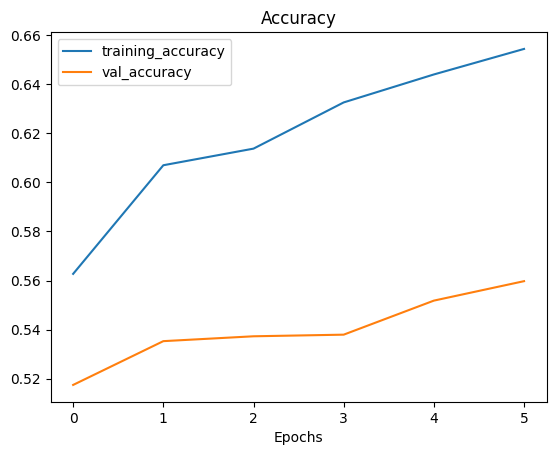

In [26]:
plot_loss_curves(history_fine_tuning)

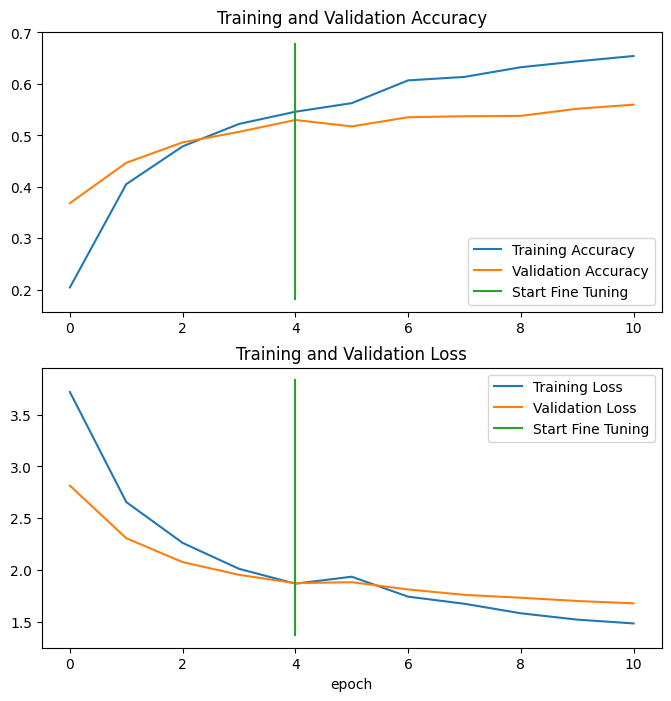

In [27]:
compare_historys(history_feature_extractions, history_fine_tuning)

## Effects of using mixed precision:
- Faster training as the computations happen between 16 bit variables rather than 32 bit ones
- Slight loss in performance
- Lesser use of GPU memory
- The loss calculations are done on fp16, but just before backpass they are scaled up to fp32 so that the gradients don't underflow and cause over/underfitting